In [1]:
# %pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift
import time
notebook_start = time.perf_counter()

import os
import json
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns, shap
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from thermoift.rng_utils import get_rng
from thermoift import MLPostprocessing, plot_correlation_heatmap, print_model_metrics
import thermoift.PLOT_SETTINGS as ps

PLOT_FOLDER = "SVM_OUTPUTS"

In [2]:
df = pd.read_csv("../interfacial_results_dataset_A1.csv")

print(f"Total samples: {len(df)}")
print(f"\ngamma statistics:")
print(df["gamma"].describe())

Total samples: 19171

gamma statistics:
count    19171.000000
mean         9.172208
std          5.362102
min          0.501979
25%          4.384029
50%          8.788374
75%         13.688527
max         21.681737
Name: gamma, dtype: float64


In [3]:
target     = "gamma"
SEED       = 455552
rng        = get_rng(seed=SEED)

z_columns  = [col for col in df.columns if col.startswith("z_")]
Z_non_zero = [col for col in z_columns if (df[col] != 0).any()]
features   = ["temperature", "pressure"] + Z_non_zero

print(f"Selected features: {features}")

X = df[features]
y = df[target]

# 70/15/15 split: first 70/30, then split 30 into 15/15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

print(f"\nTraining samples:   {X_train.shape[0]}")
print(f"Testing samples:    {X_test.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")

Selected features: ['temperature', 'pressure', 'z_carbon dioxide', 'z_hydrogen', 'z_nitrogen', 'z_argon', 'z_methane', 'z_oxygen', 'z_carbon monoxide', 'z_hydrogen sulfide']

Training samples:   13419
Testing samples:    2876
Validation samples: 2876


Feature correlations with gamma:
z_carbon dioxide      0.046910
z_hydrogen sulfide    0.026481
z_argon              -0.006766
z_methane            -0.007175
z_oxygen             -0.008759
z_nitrogen           -0.023494
z_carbon monoxide    -0.025187
z_hydrogen           -0.037987
pressure             -0.837029
temperature          -0.987980
Name: gamma, dtype: float64


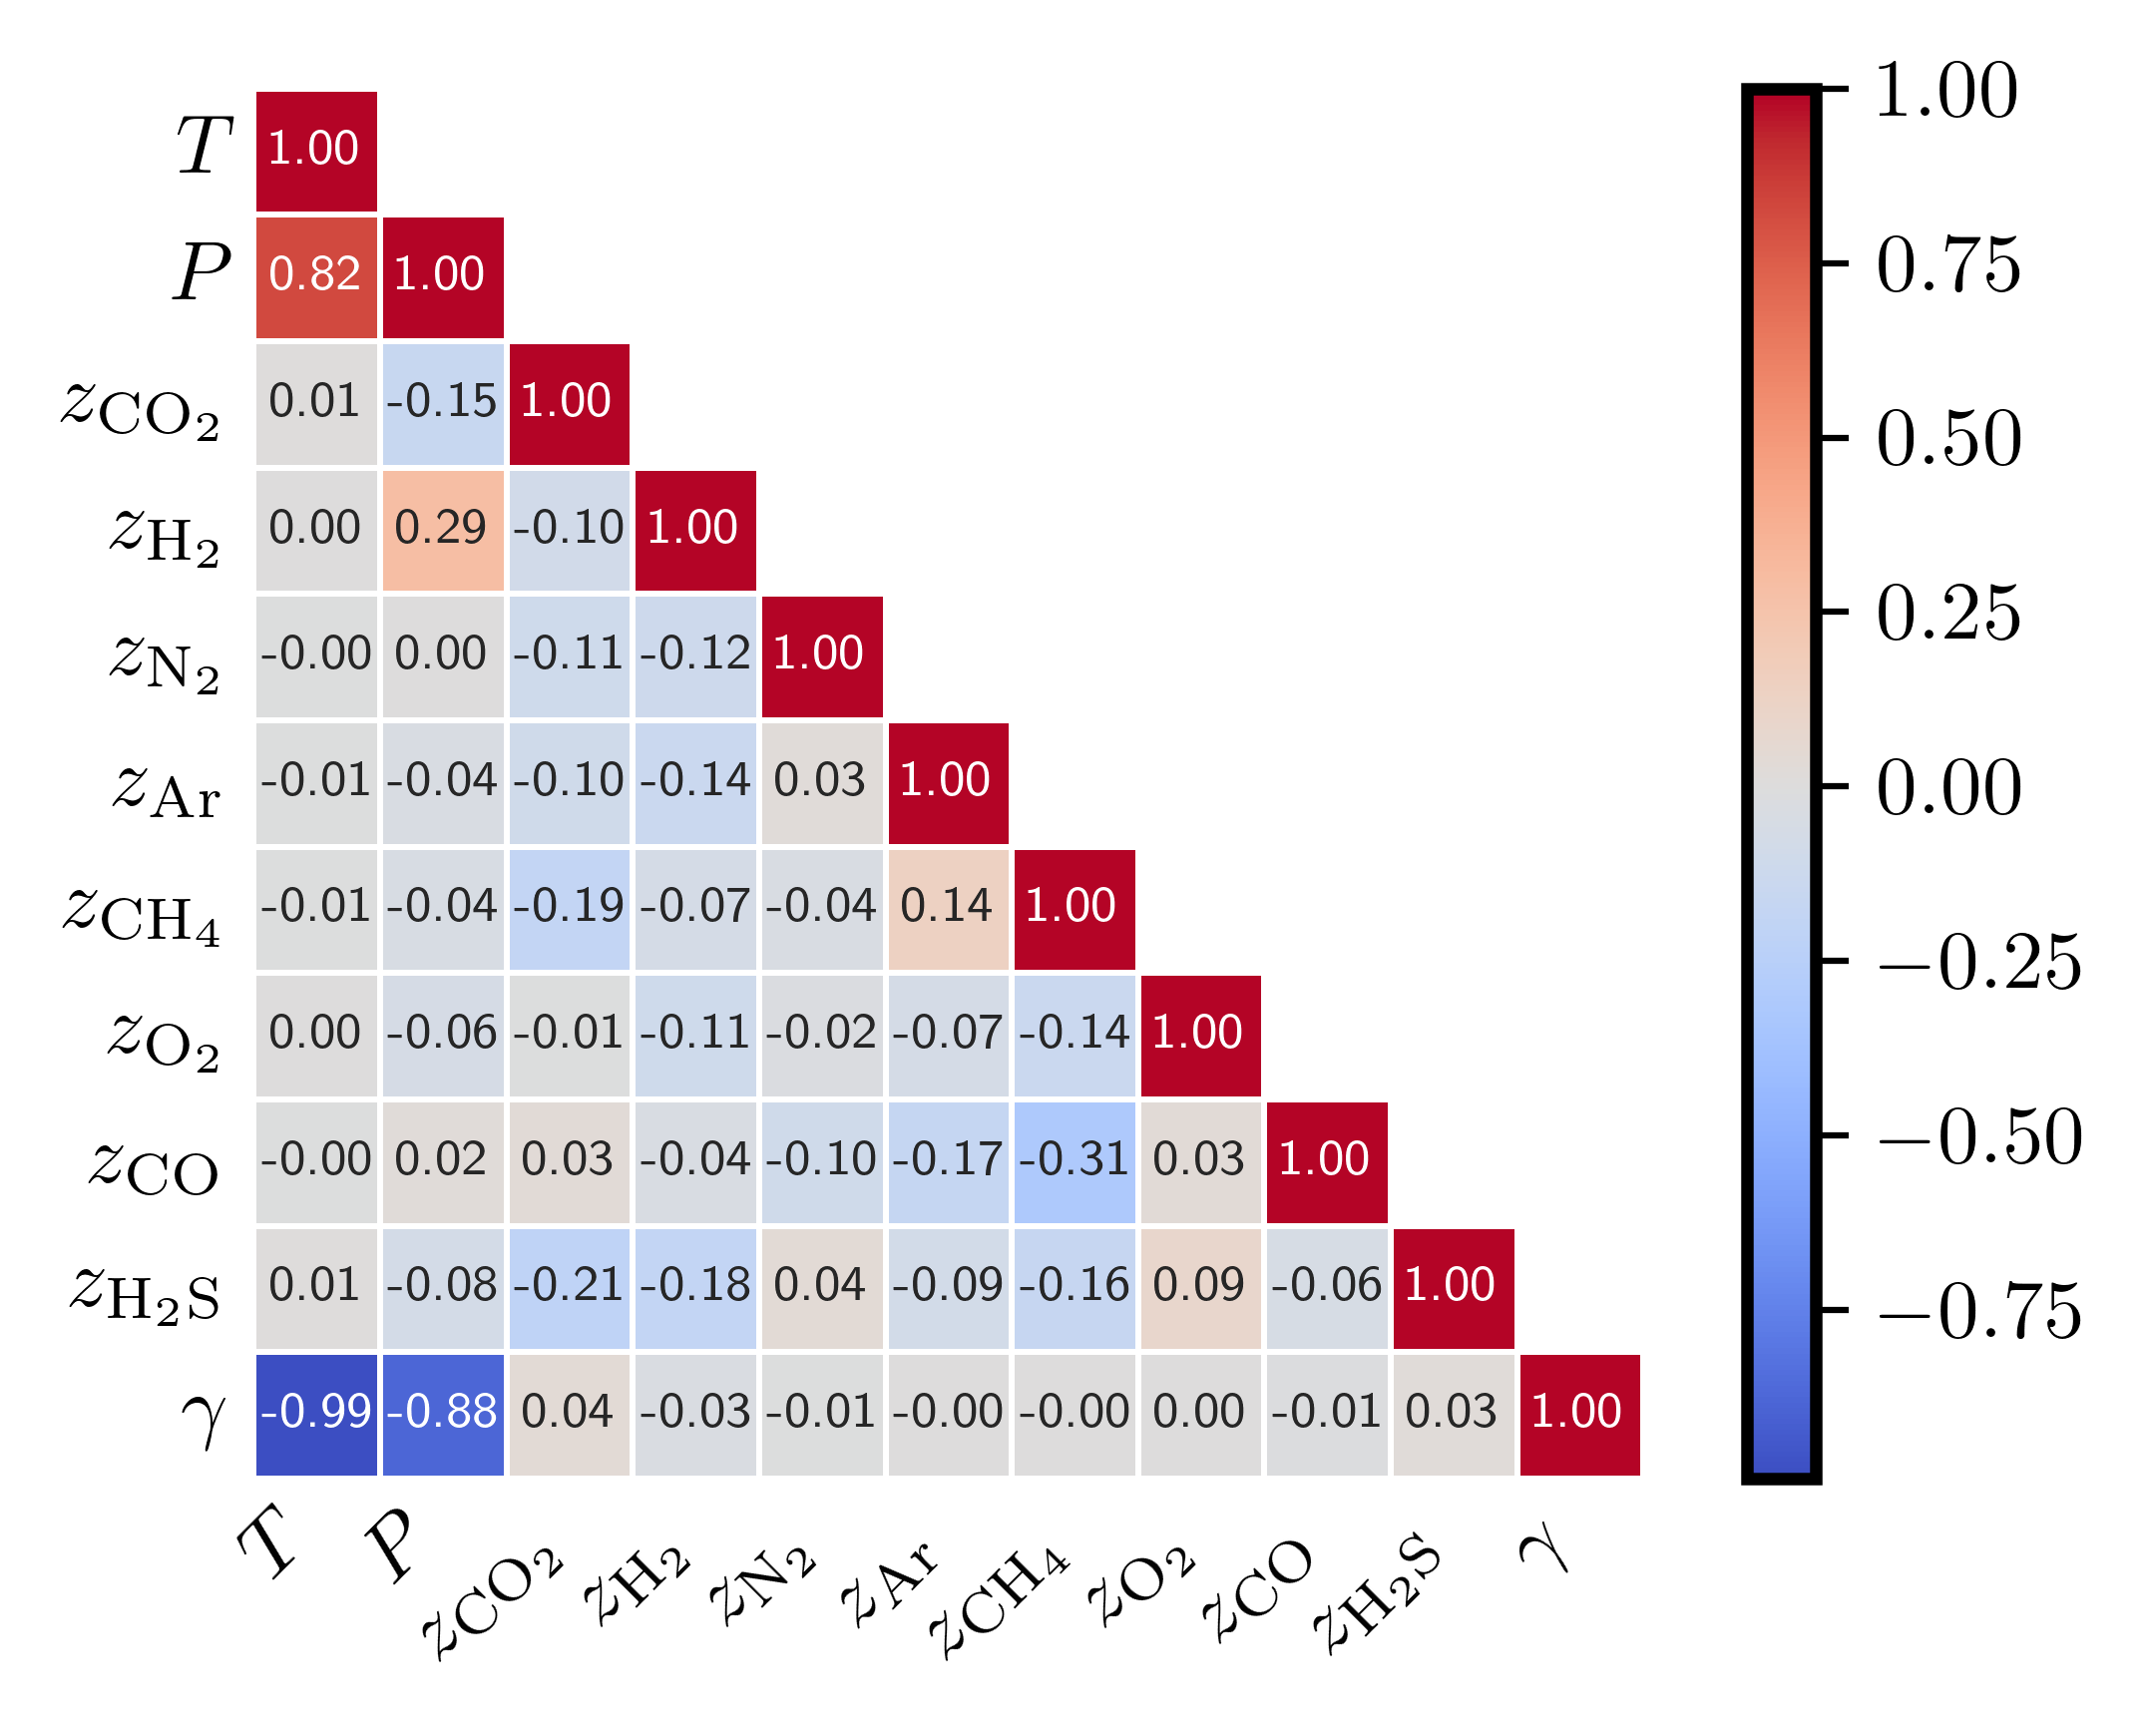

(<Figure size 2400x1800 with 2 Axes>, <Axes: >)

In [4]:
plot_correlation_heatmap(df, features, target, save_path="SVM_gamma_correlation", folder=PLOT_FOLDER)

In [5]:
# Train SVM model (SVR)
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(
        kernel="linear",    # radial basis function — best general-purpose kernel
        C=100,              # regularisation: higher = tighter fit, lower = smoother
        epsilon=0.1,        # insensitive tube half-width (in scaled units)
        # gamma="scale",      # 1 / (n_features * X.var()), auto-tuned
    ))
])

svm_model.fit(X_train, y_train)

y_train_pred    = svm_model.predict(X_train)
y_test_pred     = svm_model.predict(X_test)
y_val_pred      = svm_model.predict(X_val)

# Metrics
metrics = print_model_metrics(y_train, y_train_pred, y_test, y_test_pred, target, unit="mN/m", y_val=y_val, y_val_pred=y_val_pred)

Model Performance for gamma

Training Set:
  R²:   0.984960
  RMSE: 0.657772 mN/m
  MAE:  0.504001 mN/m

Test Set:
  R²:   0.985769
  RMSE: 0.642177 mN/m
  MAE:  0.494468 mN/m

Validation Set:
  R²:   0.985323
  RMSE: 0.646045 mN/m
  MAE:  0.493789 mN/m


In [6]:
# 5-fold cross-validation
cv_scores = cross_val_score(svm_model, X, y, cv=5, scoring='r2')

print(f"Cross-Validation R² Scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Cross-Validation R² Scores: [0.98272162 0.98767001 0.98428904 0.9850868  0.98492264]
Mean CV R²: 0.9849 (+/- 0.0032)


In [15]:
# coef_ as a direct importance
coef_importance = pd.Series(
    np.abs(svm_model.named_steps["svr"].coef_[0]),
    index=features
).sort_values(ascending=False)

print("\nDirect Coefficient Importance (|coef_|):")
print(coef_importance.to_string())


Direct Coefficient Importance (|coef_|):
temperature           4.876535
pressure              0.507094
z_hydrogen sulfide    0.182973
z_carbon dioxide      0.144439
z_carbon monoxide     0.126592
z_nitrogen            0.113634
z_argon               0.069823
z_methane             0.065367
z_oxygen              0.056898
z_hydrogen            0.021170


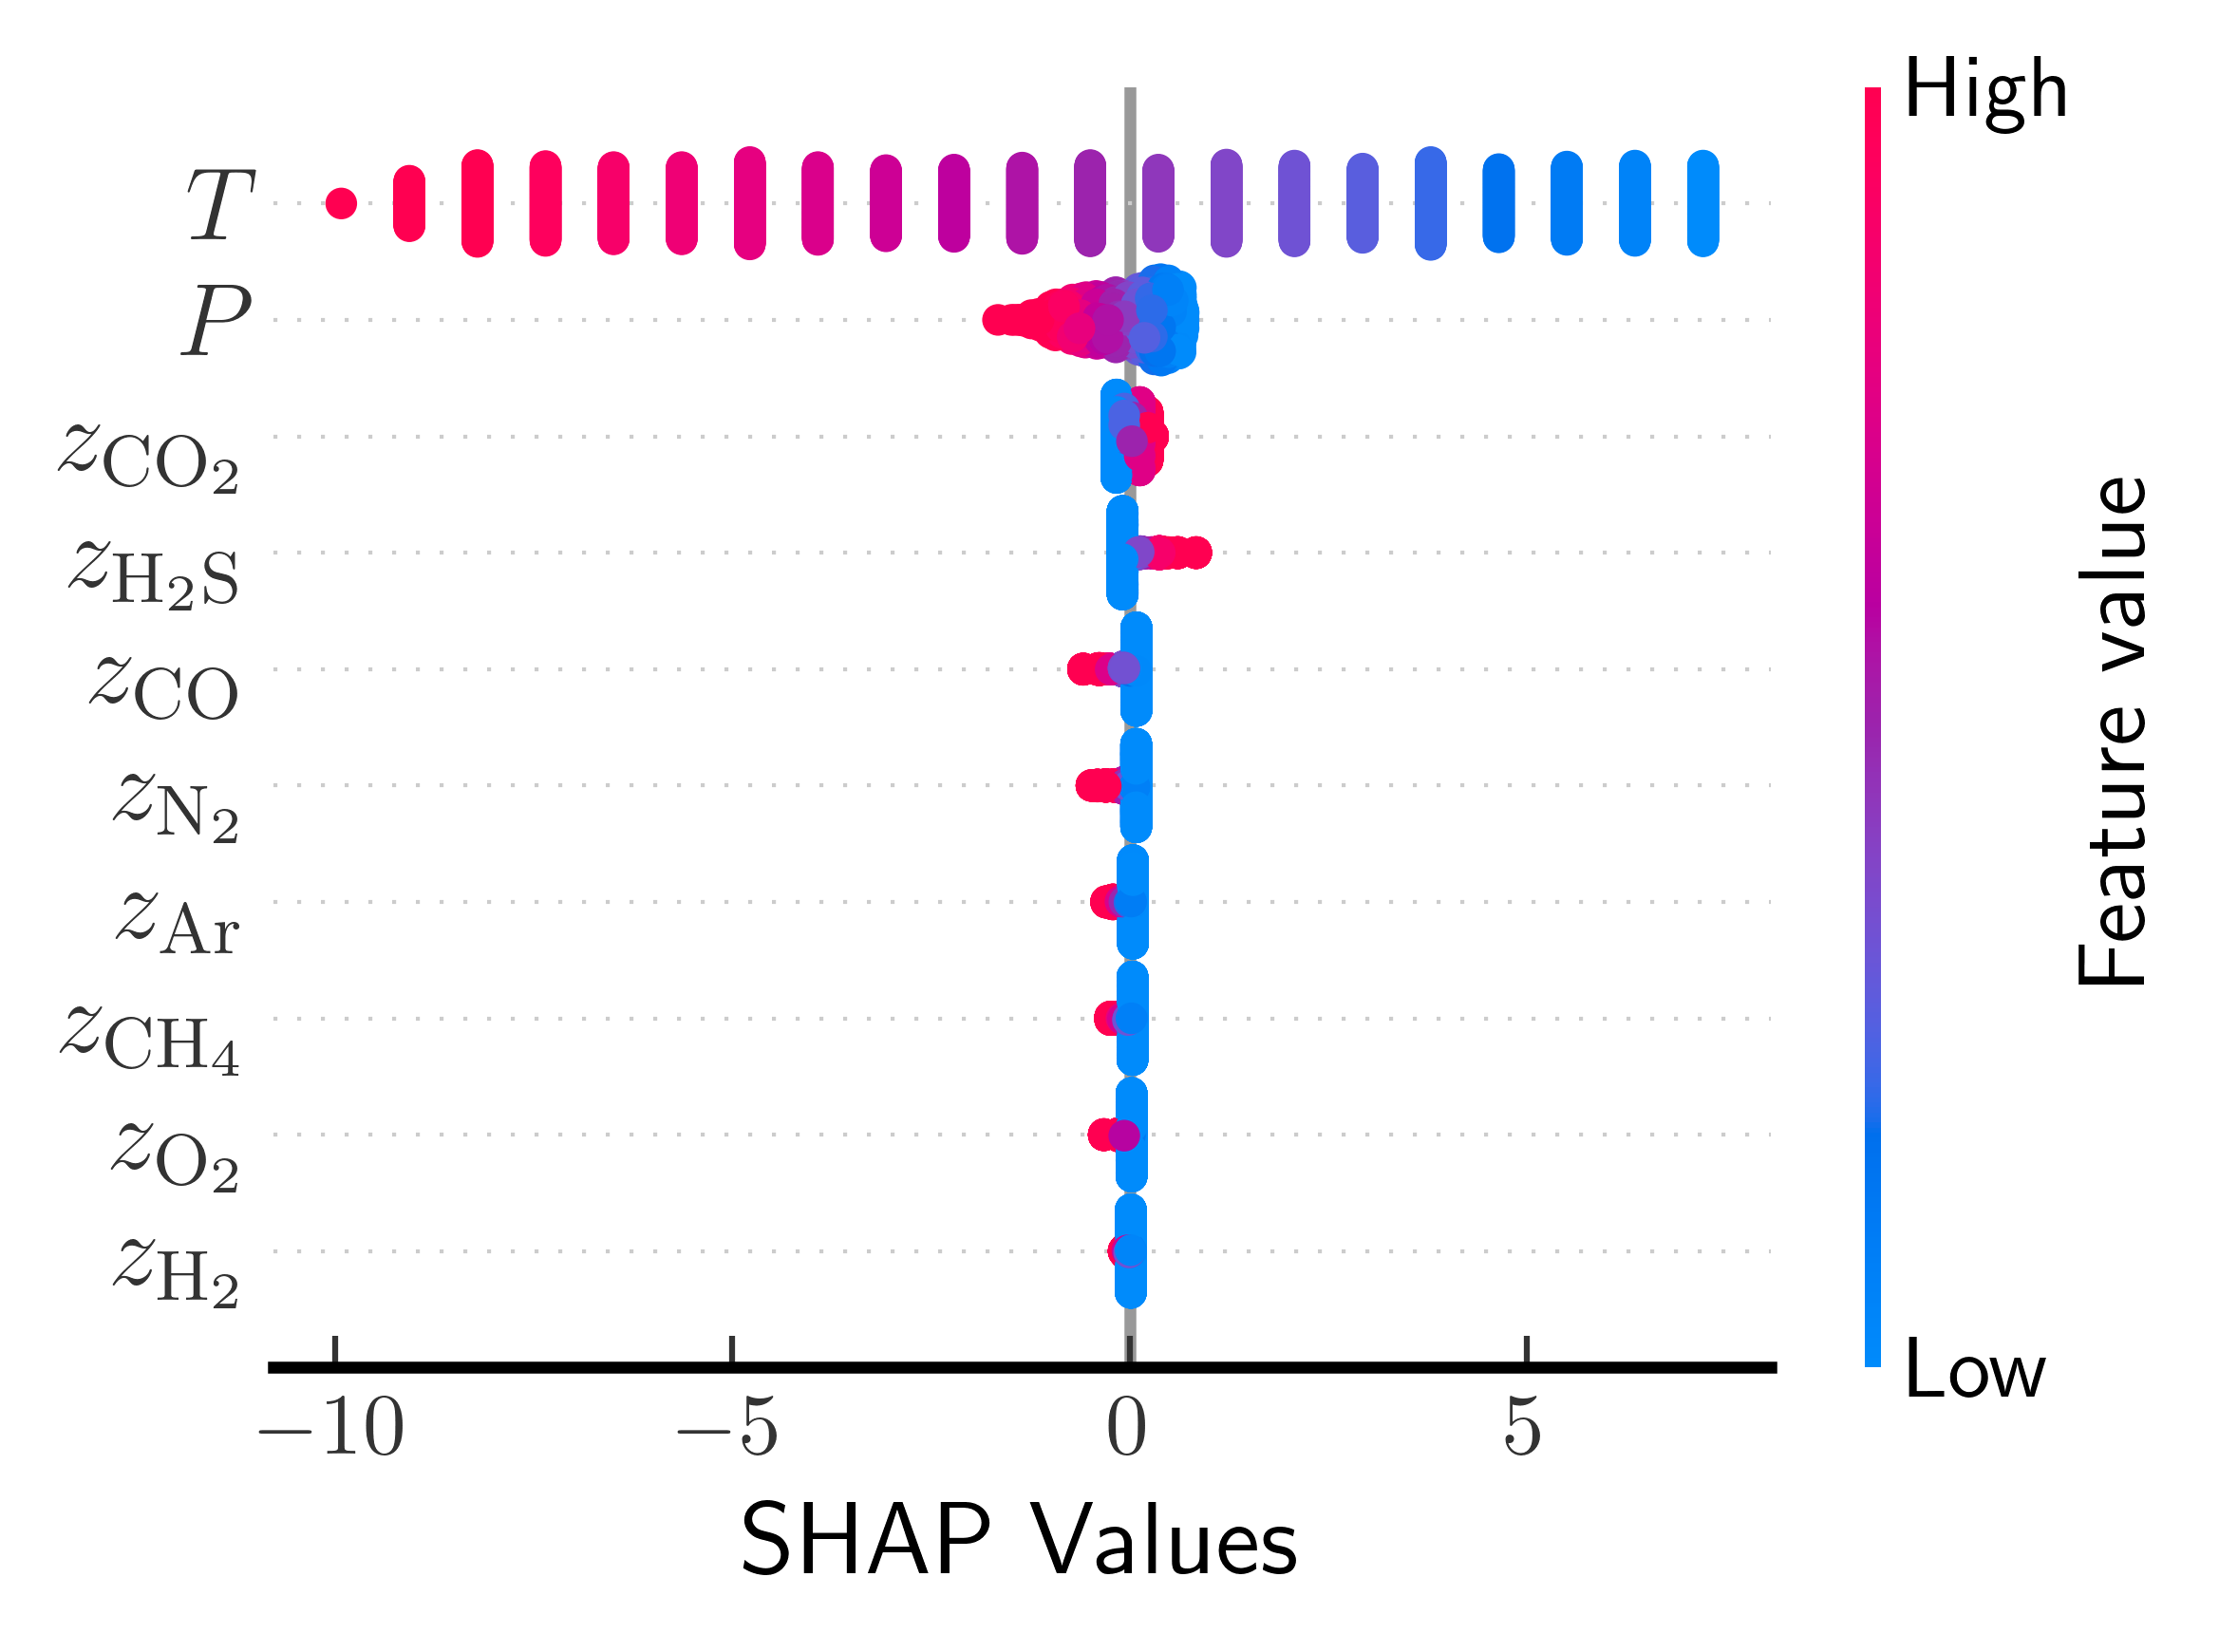

In [16]:
label_map = {
    "temperature": r"$T$",
    "pressure": r"$P$",
    "z_carbon dioxide": r"$z_{\mathrm{CO_2}}$",
    "z_hydrogen": r"$z_{\mathrm{H_2}}$",
    "z_argon": r"$z_{\mathrm{Ar}}$",
    "z_nitrogen": r"$z_{\mathrm{N_2}}$",
    "z_methane": r"$z_{\mathrm{CH_4}}$",
    "z_oxygen": r"$z_{\mathrm{O_2}}$",
    "z_carbon monoxide": r"$z_{\mathrm{CO}}$",
    "z_hydrogen sulfide": r"$z_{\mathrm{H_2S}}$",
    "gamma": r"$\gamma$",
}

# SHAP Values - SVM
scaler          = svm_model.named_steps["scaler"]
svr_step        = svm_model.named_steps["svr"]
X_train_scaled  = scaler.transform(X_train)
X_test_scaled   = scaler.transform(X_test)

explainer       = shap.LinearExplainer(svr_step, X_train_scaled)
shap_values     = explainer.shap_values(X_test_scaled)

feature_labels  = [label_map.get(f, f) for f in features]
shap_df         = pd.DataFrame(shap_values, columns=feature_labels)

# Beeswarm Summary Plot
fig, ax = ps.plot_init()
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=feature_labels,
    show=False,
    plot_size=None)

ax = plt.gca()
ax.set_xlabel("SHAP Values")

plt.tight_layout()
ps.save_plot(fig, "SVM_linear_gamma_shap_summary")
plt.show()

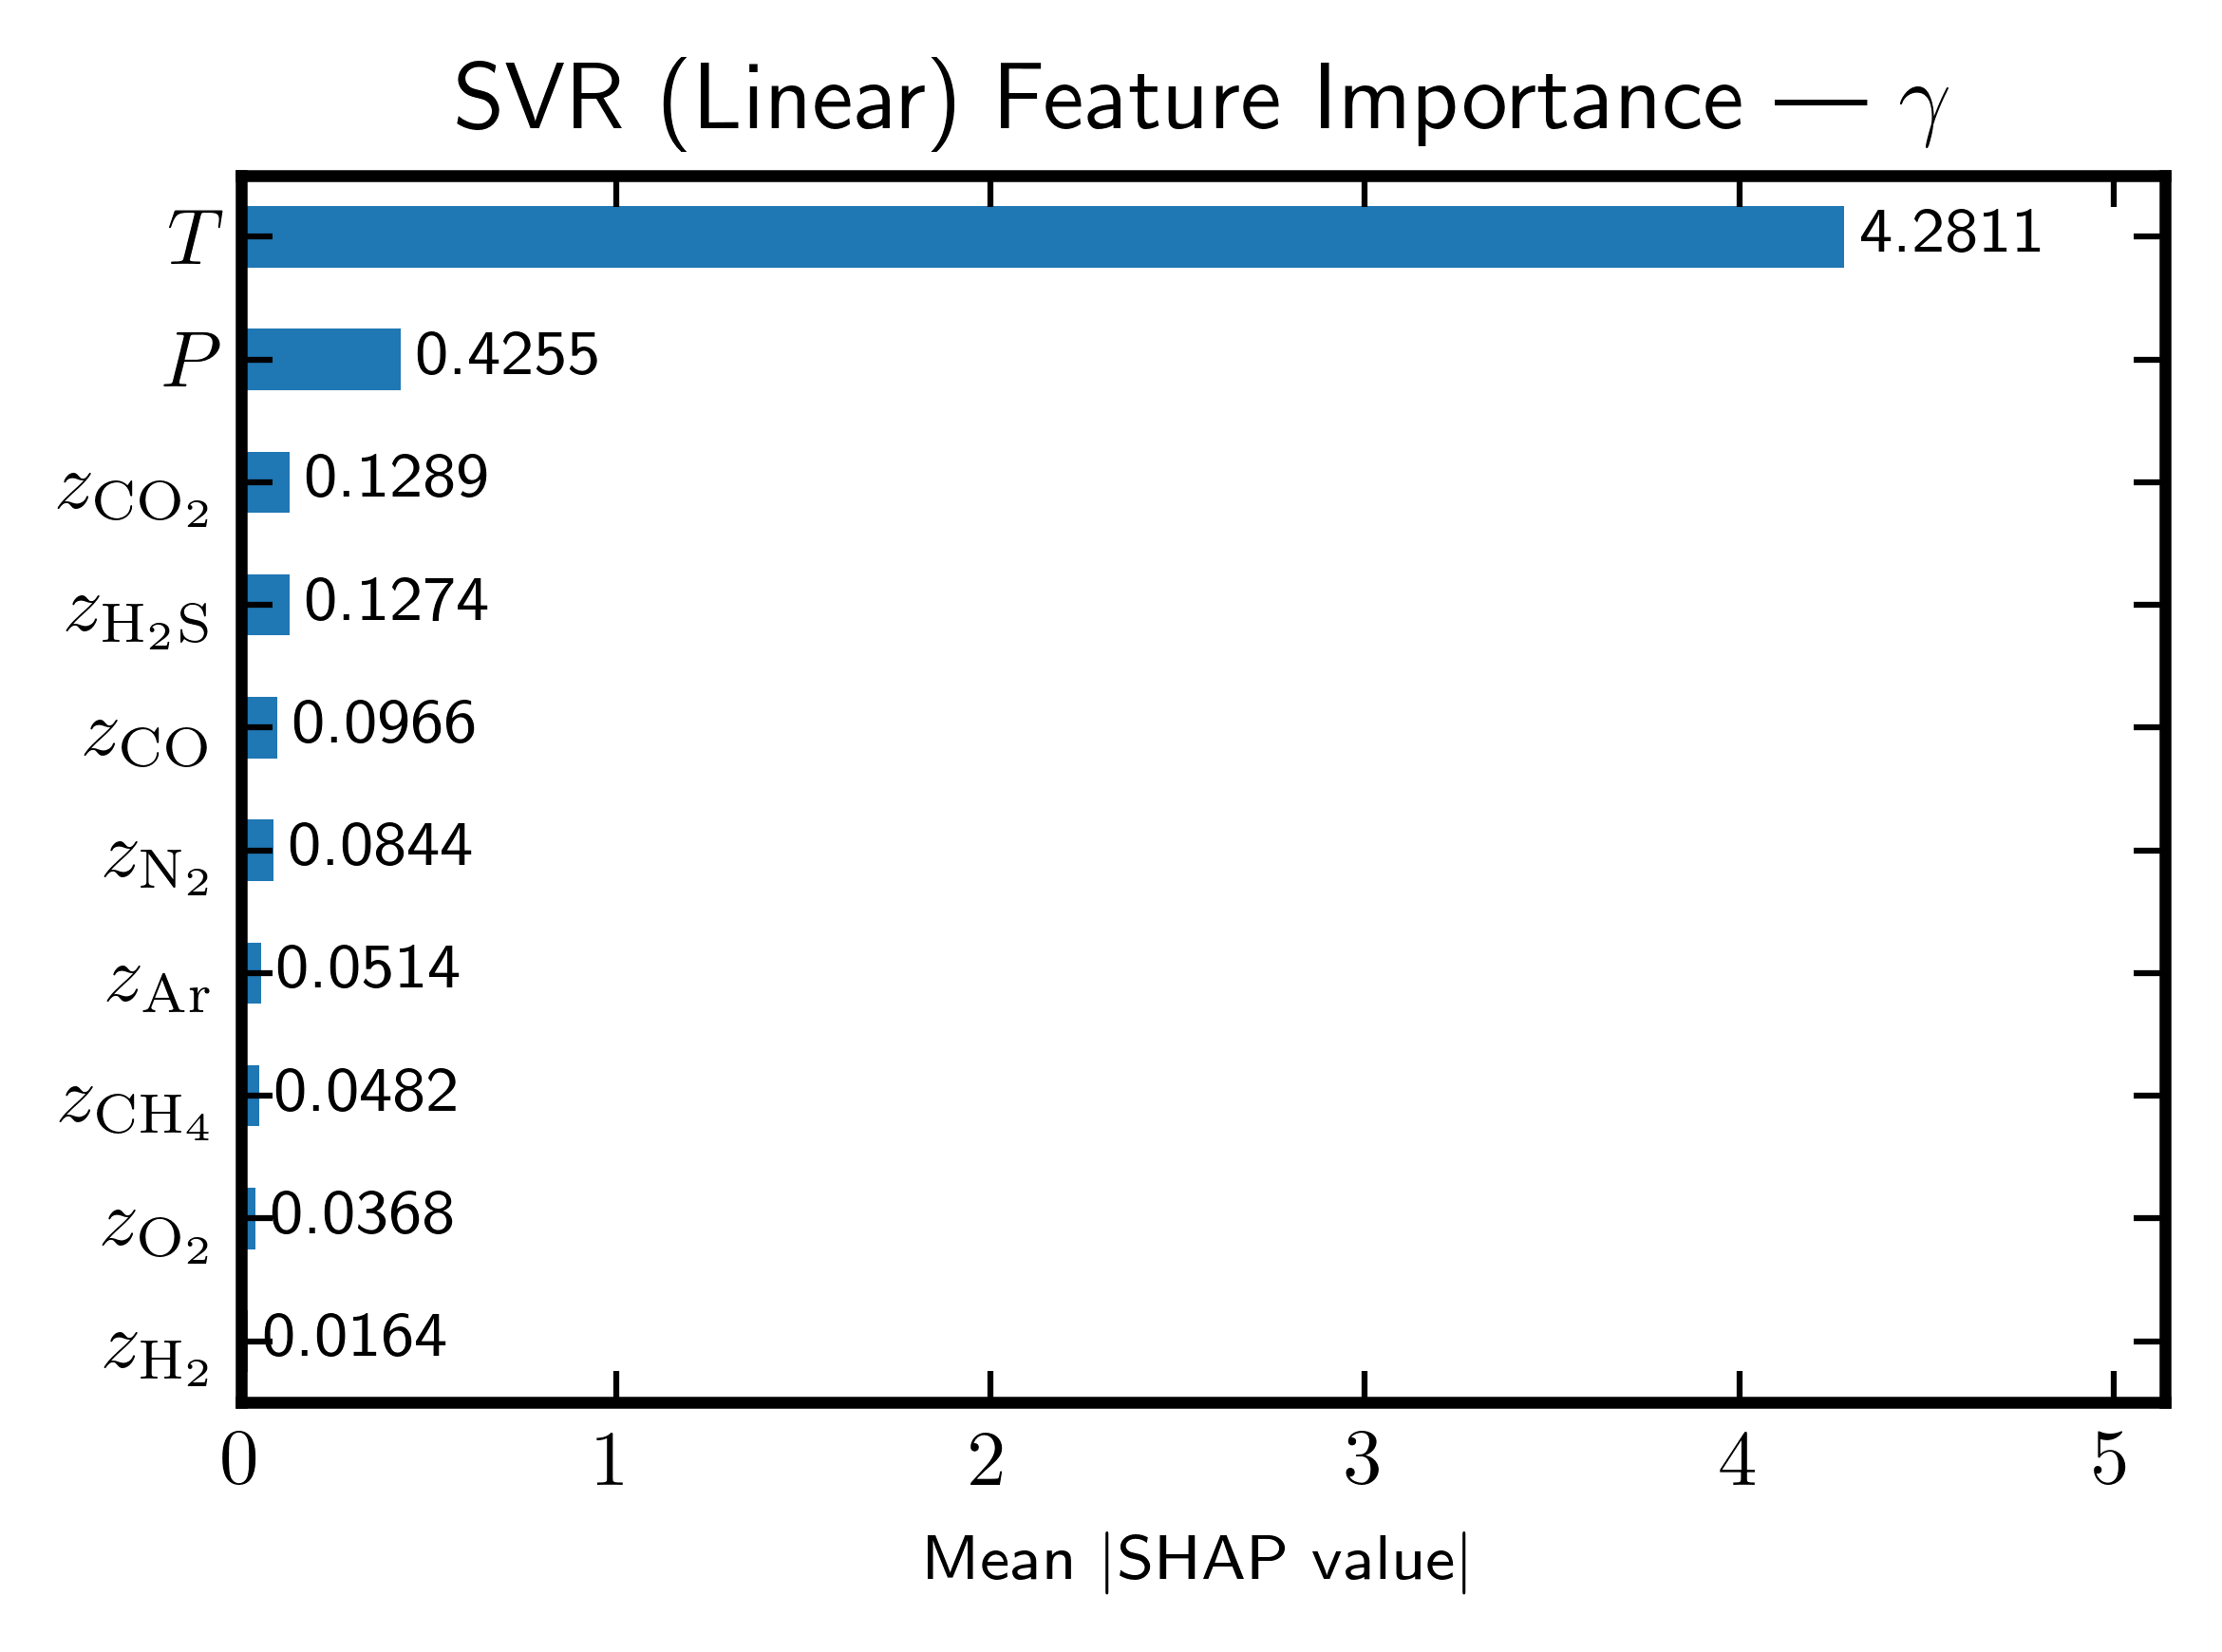

In [9]:
# Plot 2: Mean |SHAP| Bar Chart
mean_abs_shap = np.abs(shap_df).mean().sort_values(ascending=True)

fig, ax = ps.plot_init()
mean_abs_shap.plot(kind="barh", ax=ax)

# Annotate each bar with its exact value
for i, val in enumerate(mean_abs_shap):
    ax.text(
        val + 0.01 * mean_abs_shap.max(),  # small offset from bar tip
        i,
        f"{val:.4f}",
        va="center",
        ha="left",
        fontsize=8,
    )

# Expand x-axis slightly so labels don't get clipped
ax.set_xlim(0, mean_abs_shap.max() * 1.20)

ax.set_xlabel(r"Mean $|$SHAP value$|$")
ax.set_title(r"SVR (Linear) Feature Importance — $\gamma$")
ps.apply_axis_style(ax)
plt.tight_layout()
ps.save_plot(fig, "SVR_linear_gamma_shap_bar")
plt.show()

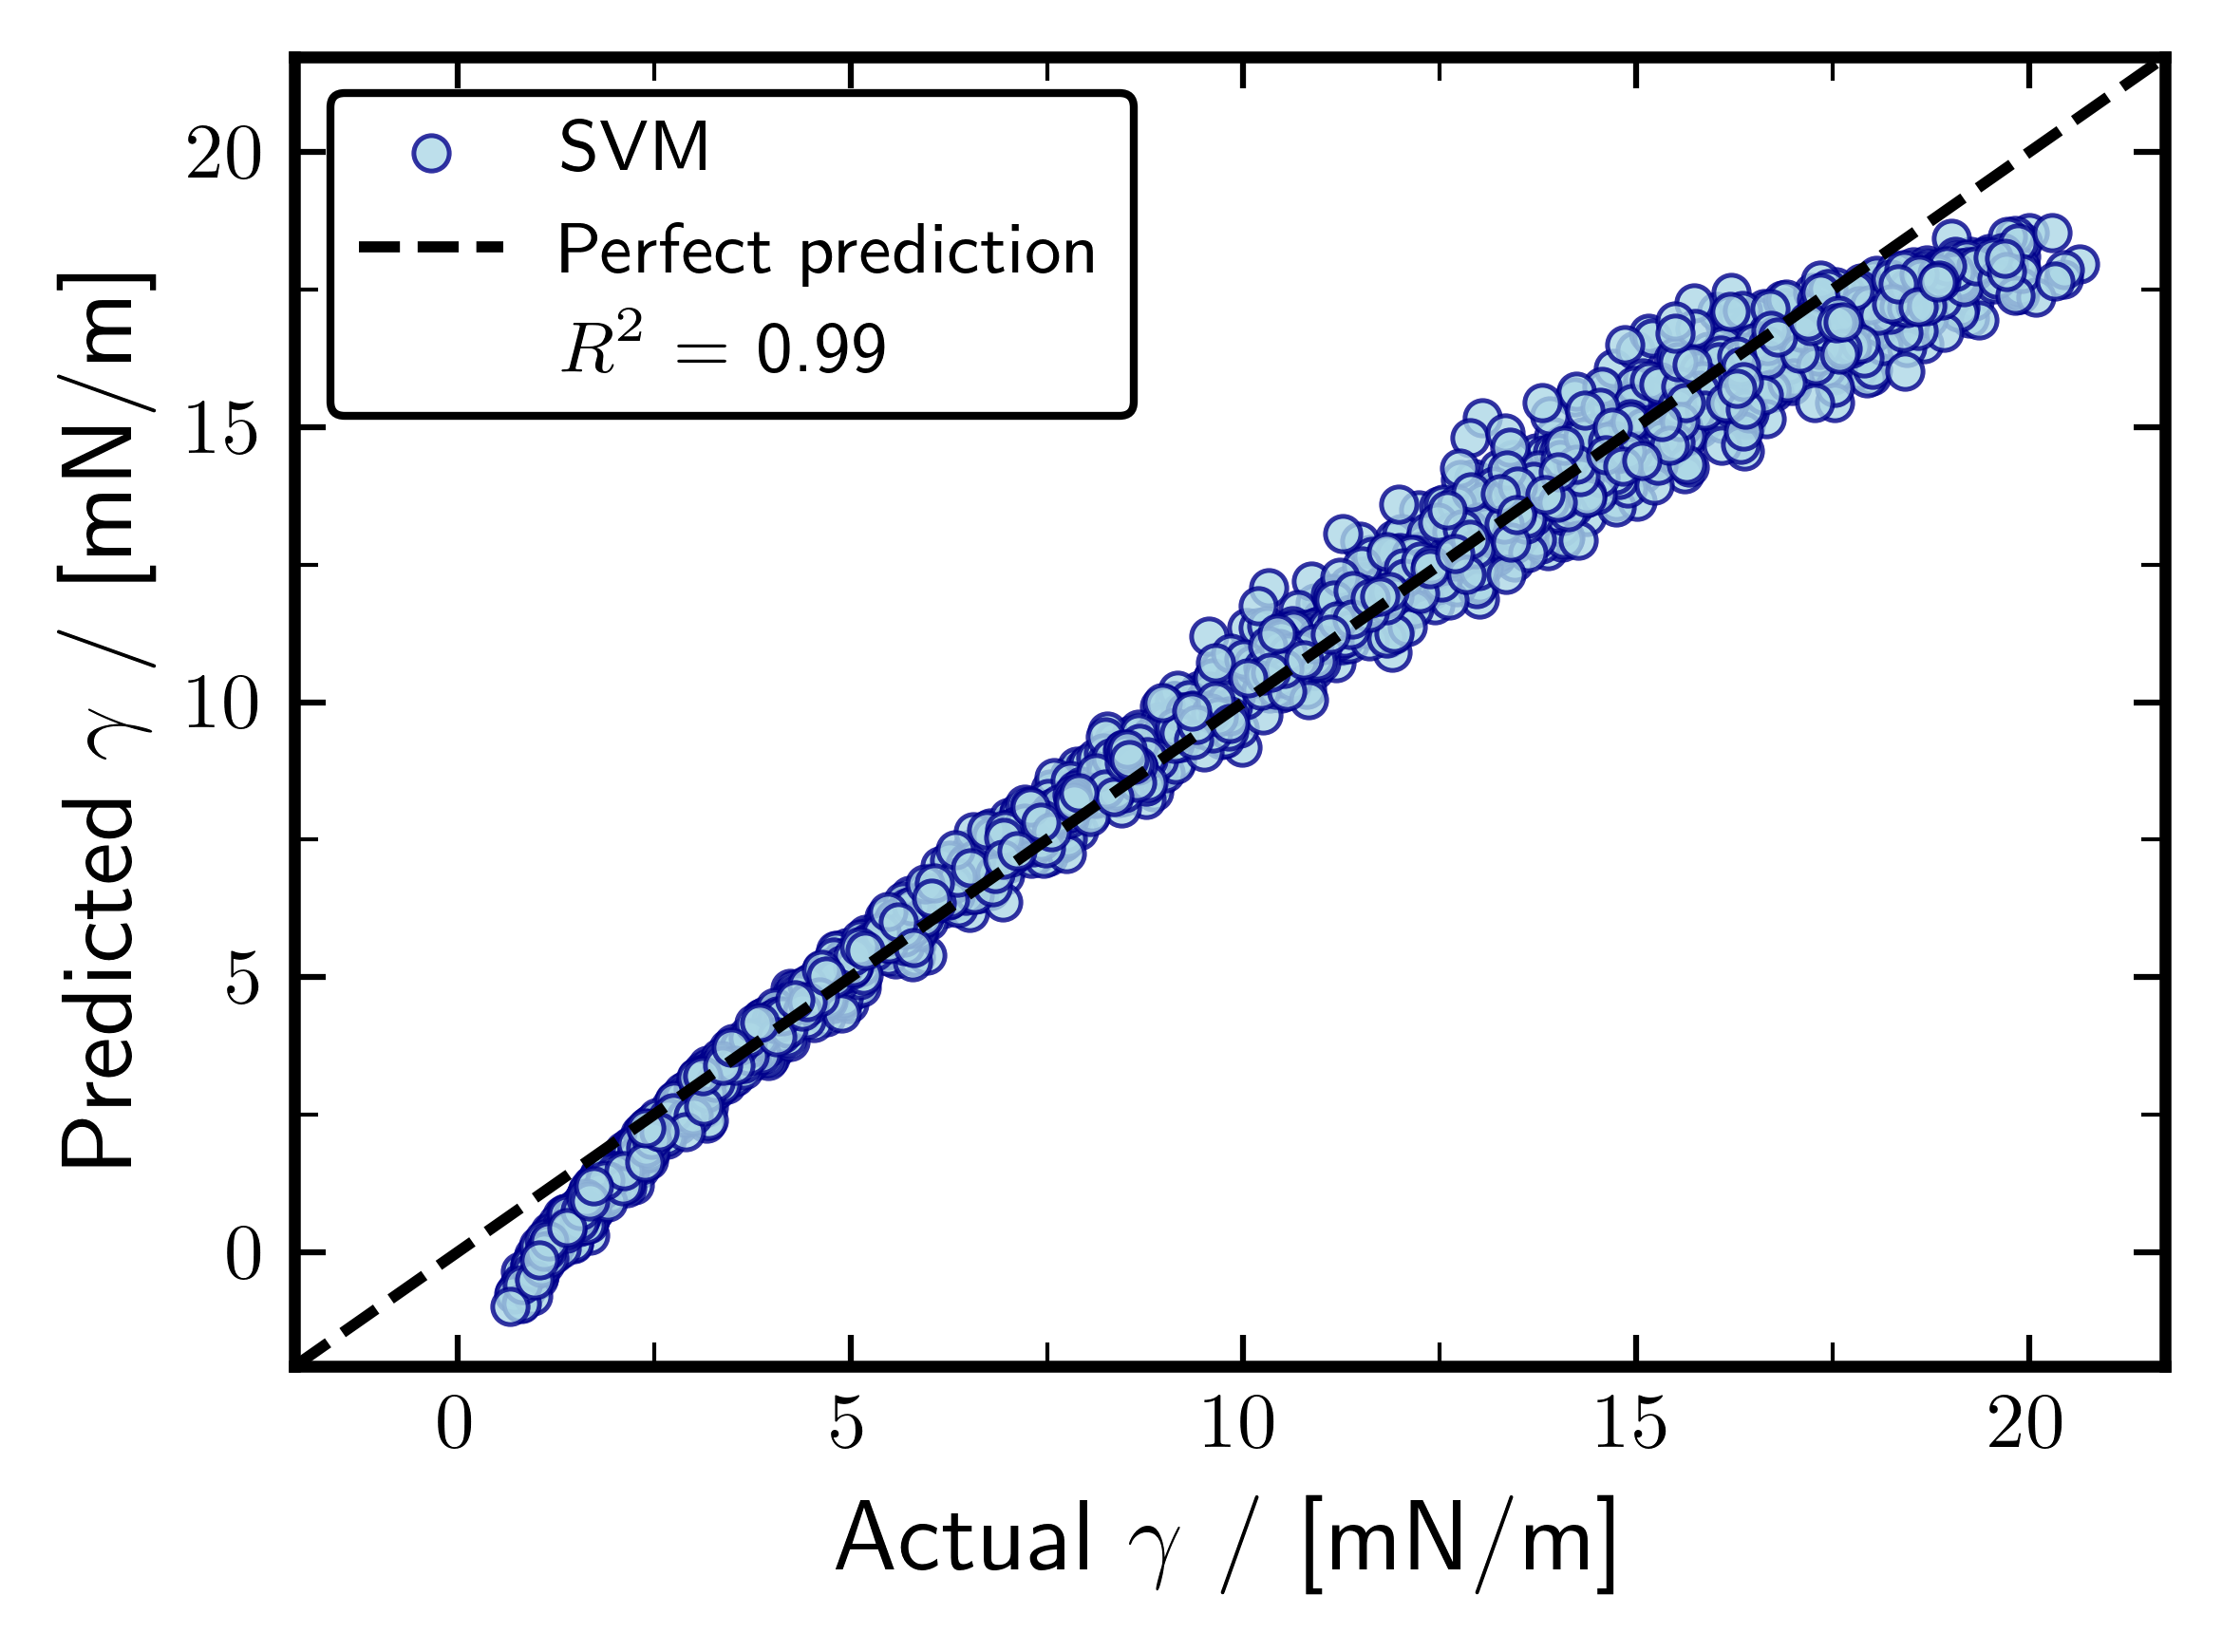

In [10]:
fig, ax = ps.plot_init()

lims = [
    min(y_test.min(), y_test_pred.min()),
    max(y_test.max(), y_test_pred.max())
]
margin = (lims[1] - lims[0]) * 0.05
lims = [lims[0] - margin, lims[1] + margin]

ax.scatter(
    y_test, y_test_pred,
    alpha=0.8, s=20,
    facecolors="lightblue",
    edgecolors="darkblue",
    linewidths=0.6,
    label="SVM"
)

ax.plot(lims, lims, "k--", linewidth=1.4, label="Perfect prediction")
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel(r"Actual $\gamma$ / [mN/m]", fontsize=ps.label_fontsize * 0.9)
ax.set_ylabel(r"Predicted $\gamma$ / [mN/m]", fontsize=ps.label_fontsize * 0.9)

ps.apply_axis_style(ax)
dummy_r2 = Line2D([], [], linestyle="none", label=rf"$R^2$ = {metrics['test_r2']:.2f}")

handles, labels = ax.get_legend_handles_labels()
handles.append(dummy_r2)

ax.legend(
    handles=handles,
    fontsize=ps.label_fontsize * 0.65,
    loc="upper left",
    edgecolor="black",
    framealpha=1.0
)

ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis="both", which="minor", length=3)

plt.tight_layout()
ps.save_plot(fig, "SVR_linear_gamma_parity_plot")
plt.show()

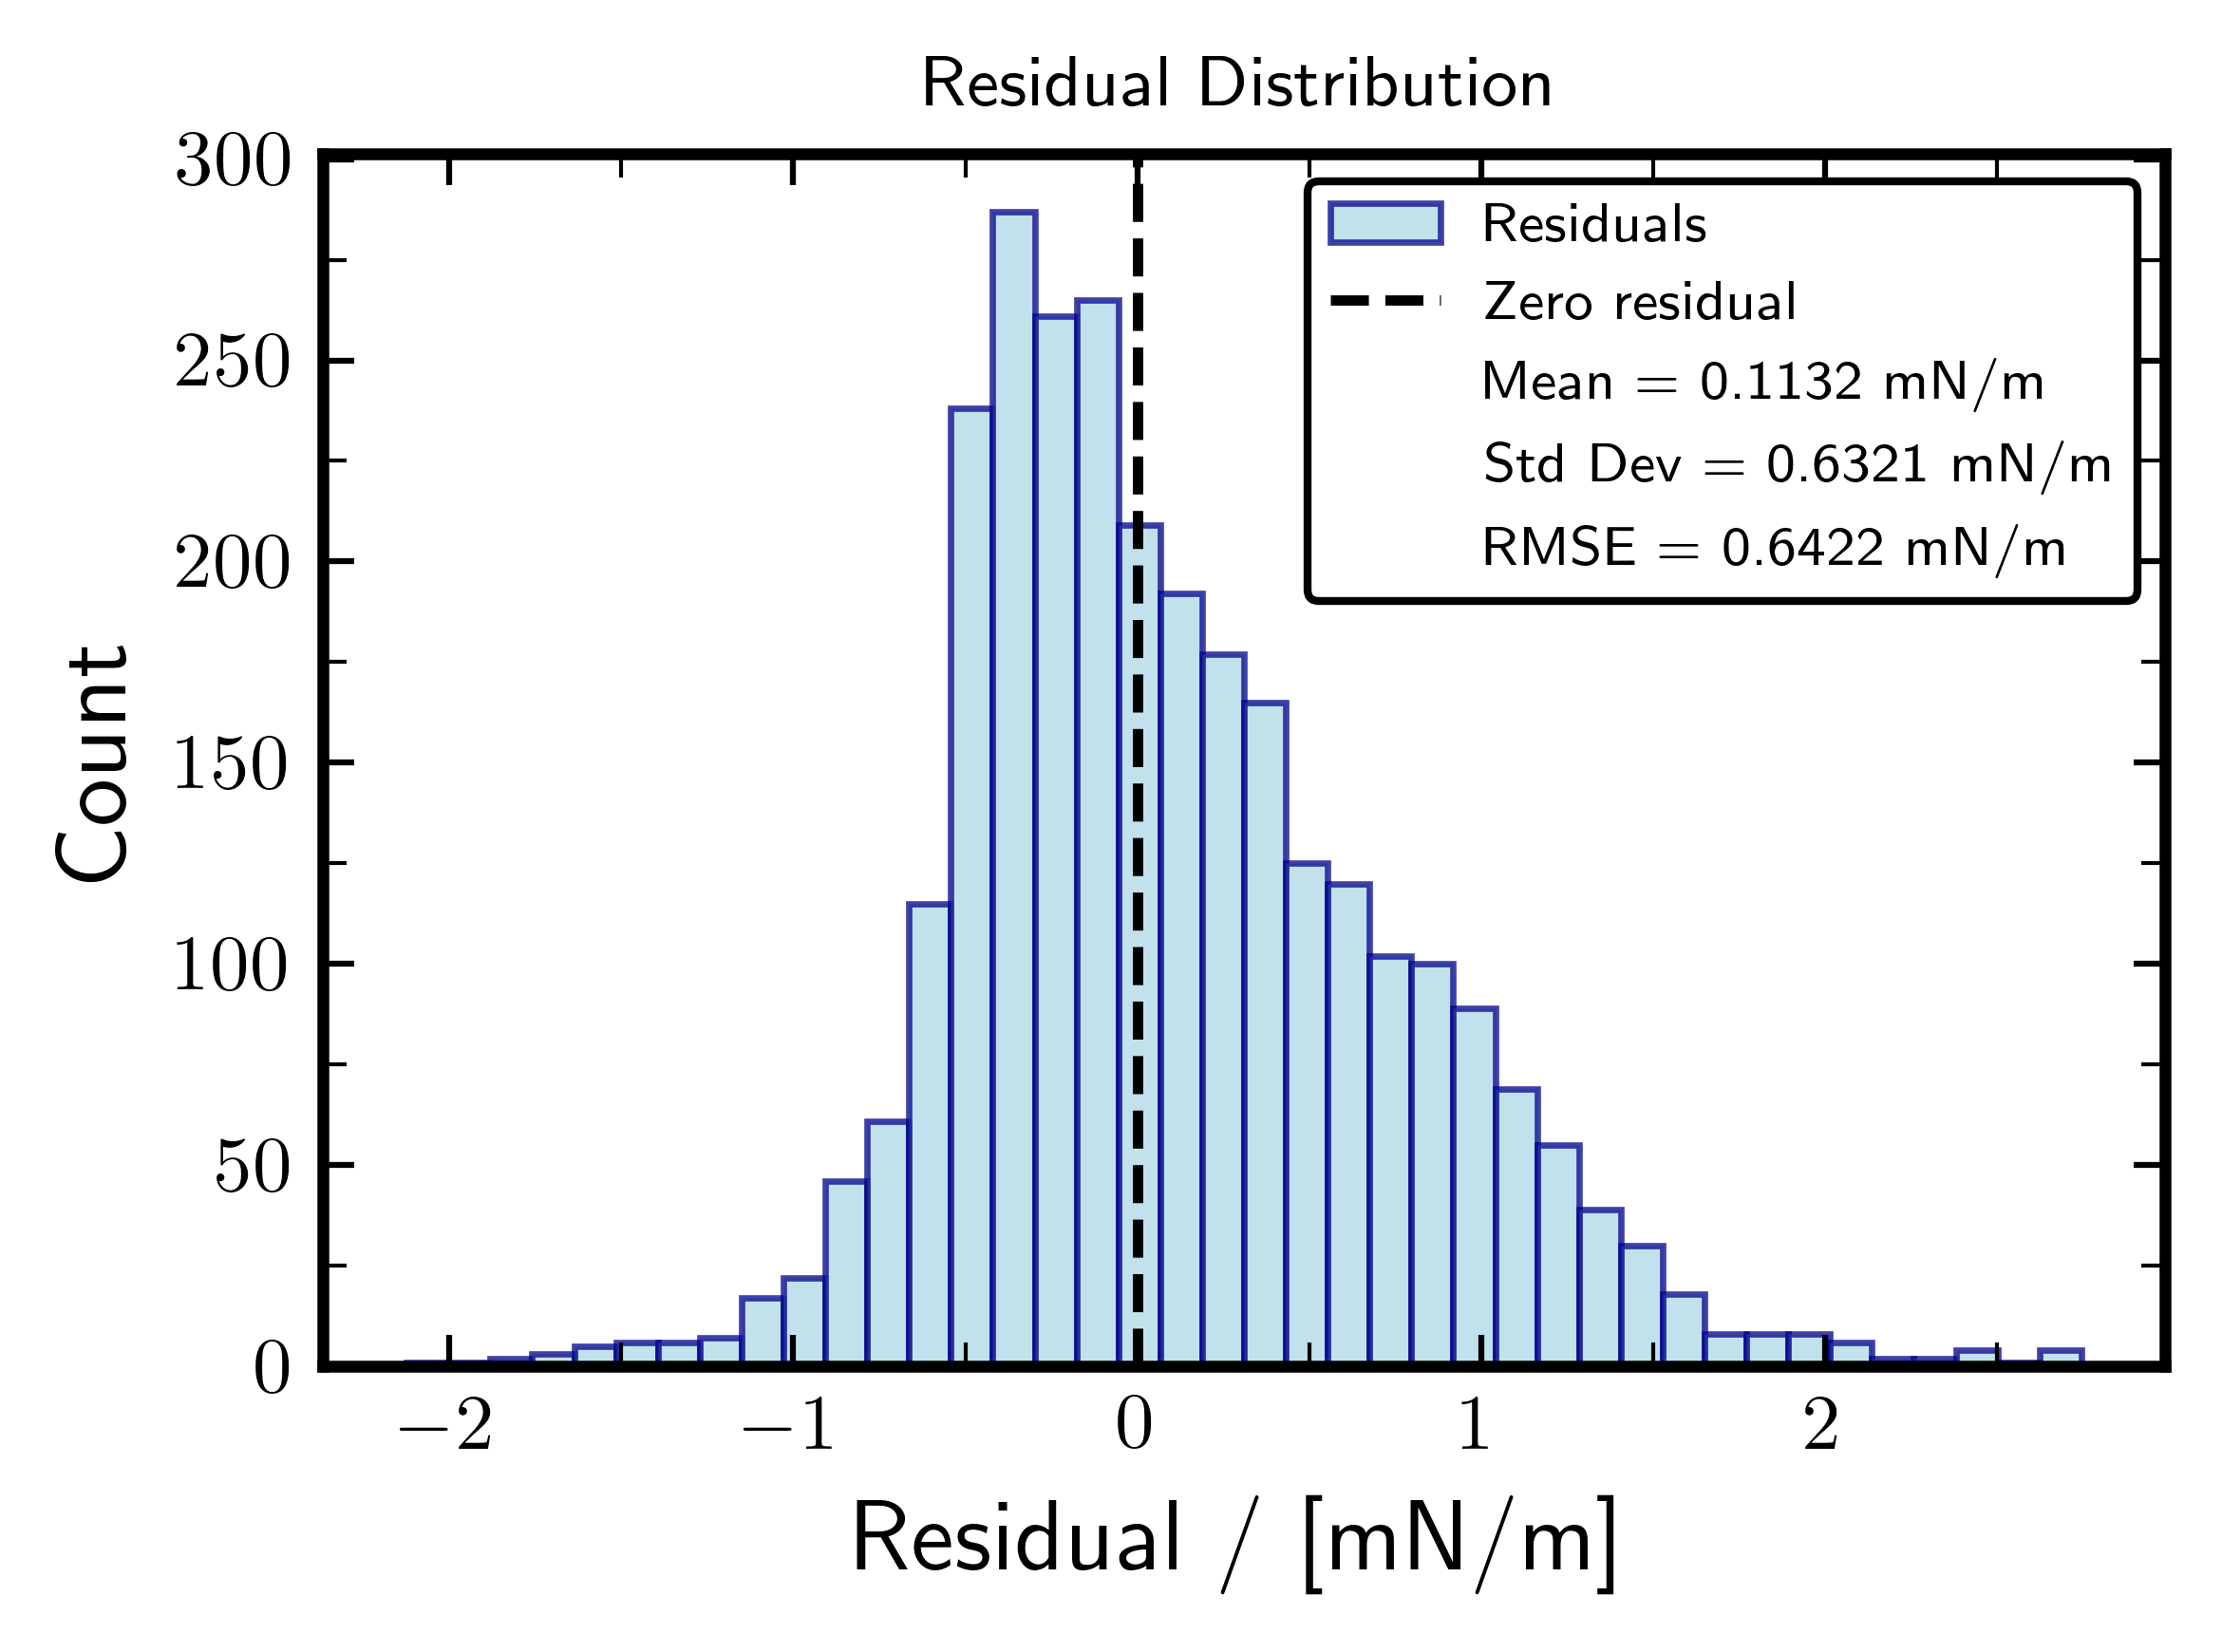

In [11]:
# Residual distribution — SVM
residuals = y_test.values - y_test_pred

fig, ax = ps.plot_init()

ax.hist(
    residuals,
    bins=40,
    alpha=0.75,
    color="lightblue",
    edgecolor="darkblue",
    linewidth=0.8,
    label="Residuals"
)

ax.axvline(0, color="black", linewidth=1.3, linestyle="--", label="Zero residual")

mean_resid = residuals.mean()
std_resid  = residuals.std()

ax.set_xlabel(r"Residual / [mN/m]", fontsize=ps.label_fontsize * 0.9)
ax.set_ylabel(r"Count", fontsize=ps.label_fontsize * 0.9)
ax.set_title(r"Residual Distribution", fontsize=ps.title_fontsize * 0.75, fontweight="bold")

dummy_mean = Line2D([], [], linestyle="none", label=rf"Mean = {mean_resid:.4f} mN/m")
dummy_std  = Line2D([], [], linestyle="none", label=rf"Std Dev = {std_resid:.4f} mN/m")
dummy_rmse = Line2D([], [], linestyle="none", label=rf"RMSE = {metrics['test_rmse']:.4f} mN/m")

handles, labels = ax.get_legend_handles_labels()
handles.extend([dummy_mean, dummy_std, dummy_rmse])

ps.apply_axis_style(ax)

ax.legend(
    handles=handles,
    fontsize=ps.label_fontsize * 0.5,
    loc="upper right",
    edgecolor="black",
    facecolor="white",
    framealpha=1.0
)

ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis="both", which="minor", length=3)

plt.tight_layout()
ps.save_plot(fig, "SVR_linear_gamma_residual_distribution")
plt.show()

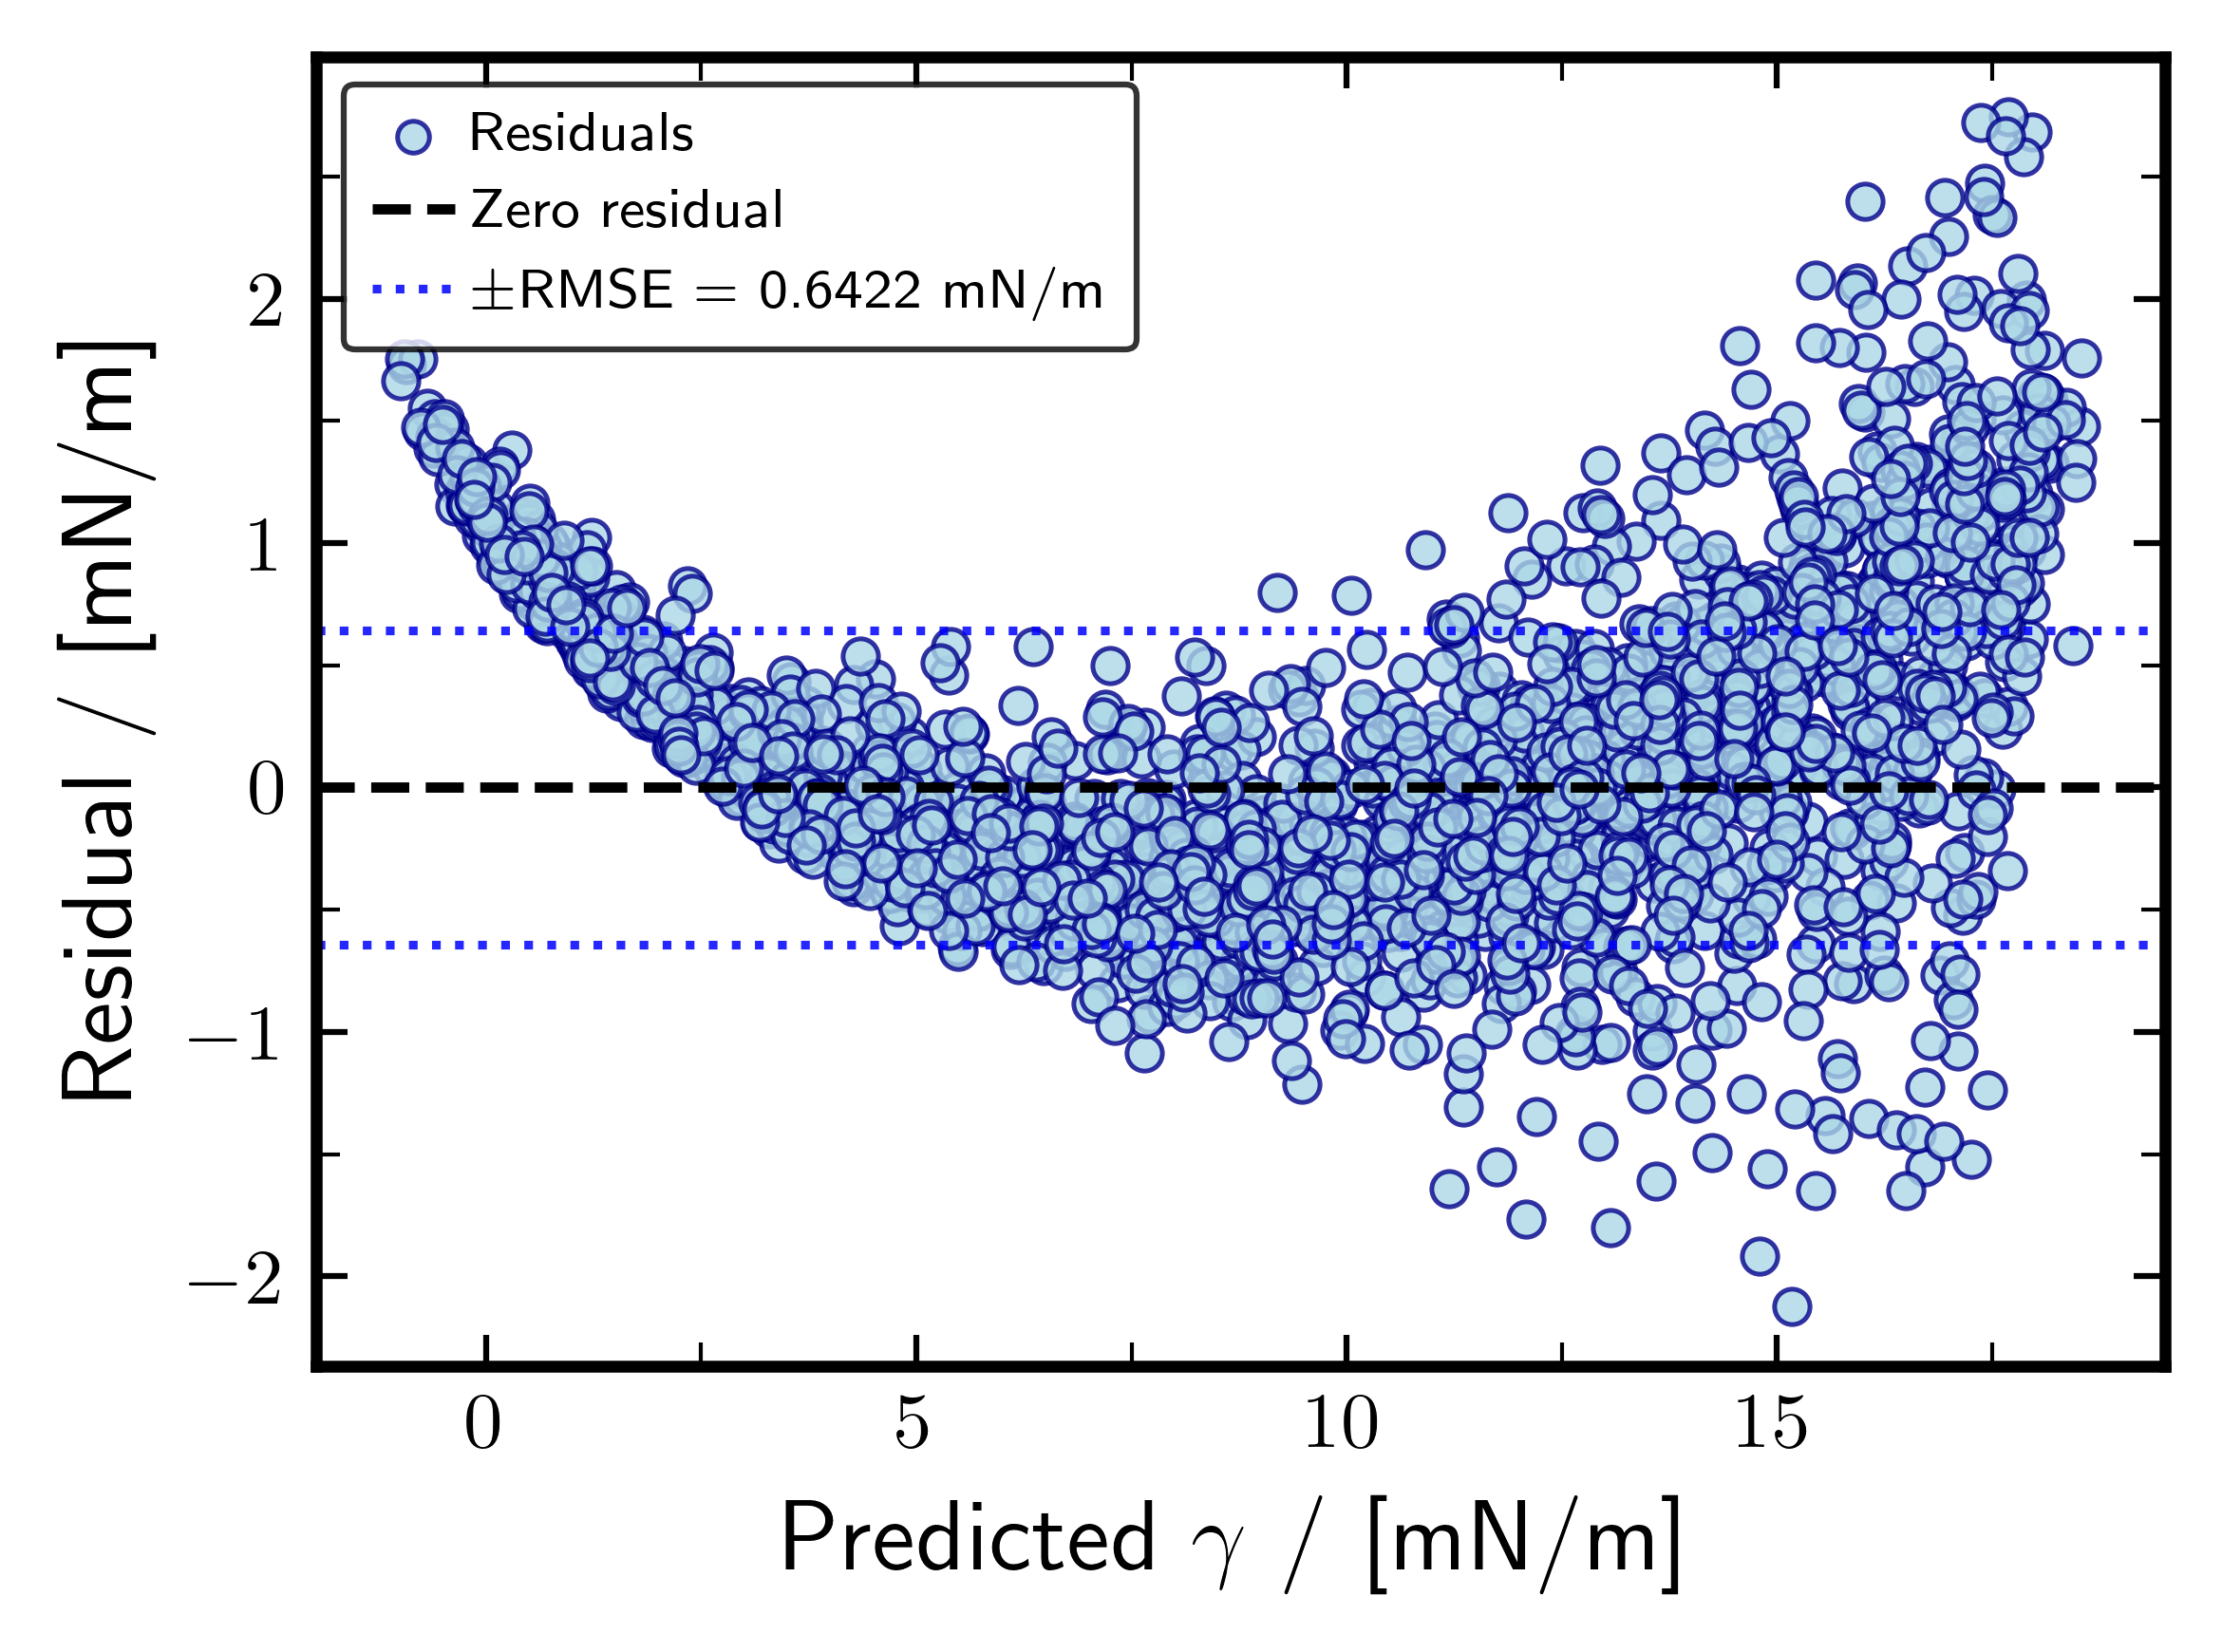

In [12]:
# Residuals vs Predicted — SVM
fig, ax = ps.plot_init()

ax.scatter(y_test_pred, residuals, alpha=0.8, s=20, facecolors="lightblue", edgecolors="darkblue", linewidths=0.6, label="Residuals")

ax.axhline(0, color="black", linewidth=1.3, linestyle="--", label="Zero residual")
ax.axhline(metrics['test_rmse'], color="blue", linewidth=1.1, linestyle=":", alpha=0.85, label=rf"$\pm$RMSE = {metrics['test_rmse']:.4f} mN/m")
ax.axhline(-metrics['test_rmse'], color="blue", linewidth=1.1, linestyle=":", alpha=0.85)

ax.set_xlabel(r"Predicted $\gamma$ / [mN/m]", fontsize=ps.label_fontsize * 0.9)
ax.set_ylabel(r"Residual / [mN/m]", fontsize=ps.label_fontsize * 0.9)

ps.apply_axis_style(ax)
ps.style_legend(ax, fontsize=ps.label_fontsize * 0.5, loc="upper left")

ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis="both", which="minor", length=3)

plt.tight_layout()
ps.save_plot(fig, "SVR_linear_gamma_residual_vs_predicted")
plt.show()

In [13]:
# Collect and save all metrics
metrics["cv_r2_scores"]  = cv_scores.tolist()
metrics["cv_r2_mean"]    = float(cv_scores.mean())
metrics["cv_r2_std"]     = float(cv_scores.std())
metrics["model"]         = "SVR_linear"
metrics["kernel"]        = svm_model.named_steps["svr"].kernel
metrics["C"]             = svm_model.named_steps["svr"].C
metrics["epsilon"]       = svm_model.named_steps["svr"].epsilon
metrics["features"]      = features
metrics["target"]        = target
metrics["seed"]          = SEED

os.makedirs(PLOT_FOLDER, exist_ok=True)
metrics_path = os.path.join(PLOT_FOLDER, f"SVM_{target}_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2, default=str)

print(f"\nMetrics saved to: {metrics_path}")


Metrics saved to: SVM_OUTPUTS/SVM_gamma_metrics.json


In [14]:
notebook_end = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")

Total notebook runtime: 32.90 minutes
